In [1]:
import numpy as np
import pandas as pd, os, datetime

# Statistical analysis
from scipy import stats
import math
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# plottinng
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.dates as mdates
import folium

from IPython.display import HTML


In [2]:
df = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv')

In [3]:
clust_df = df.query("DUID != 'CATHROCK'").copy()
piv_df = clust_df.pivot_table(columns='hour', index='DUID', values='median_diff')

In [4]:
def smooth_curve(delta, window=3):
    return (
        pd.Series(delta)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

df_smooth = piv_df.apply(
    lambda row: smooth_curve(row.values),
    axis=1,
    result_type="expand"
)

In [5]:
# Use PCA on smoothed curves for clustering
X = df_smooth.values

# Scale curves across hours
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (retain 95% of variance)
pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("PCA components:", X_pca.shape[1])

PCA components: 4


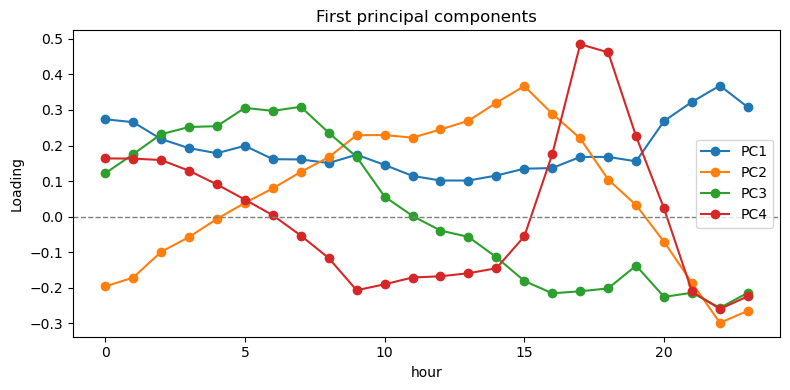

In [6]:
# Plot principal component loadings across hour of day
components = pca.components_

# Number of components and corresponding hour axis
n_components = components.shape[0]
hours = df_smooth.columns.to_numpy().astype(float)

# Plot the first few components (e.g. up to 3)
n_to_plot = min(4, n_components)
plt.figure(figsize=(8, 4))
for i in range(n_to_plot):
    plt.plot(hours, components[i], marker="o", label=f"PC{i+1}")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("hour")
plt.ylabel("Loading")
plt.title("First principal components")
plt.legend()
plt.tight_layout()
plt.show()

k= 2  silhouette=0.291  inertia=760.3
k= 3  silhouette=0.356  inertia=496.1
k= 4  silhouette=0.247  inertia=439.4
k= 5  silhouette=0.251  inertia=306.7
k= 6  silhouette=0.279  inertia=255.3
k= 7  silhouette=0.292  inertia=214.7
k= 8  silhouette=0.271  inertia=207.1
k= 9  silhouette=0.265  inertia=190.8
k=10  silhouette=0.281  inertia=169.6
k=11  silhouette=0.281  inertia=145.2
k=12  silhouette=0.288  inertia=120.3
k=13  silhouette=0.279  inertia=109.8
k=14  silhouette=0.258  inertia=102.9
k=15  silhouette=0.247  inertia=96.7
k=16  silhouette=0.249  inertia=87.1
k=17  silhouette=0.262  inertia=78.0
k=18  silhouette=0.257  inertia=71.0
k=19  silhouette=0.239  inertia=68.8
k=20  silhouette=0.207  inertia=66.1


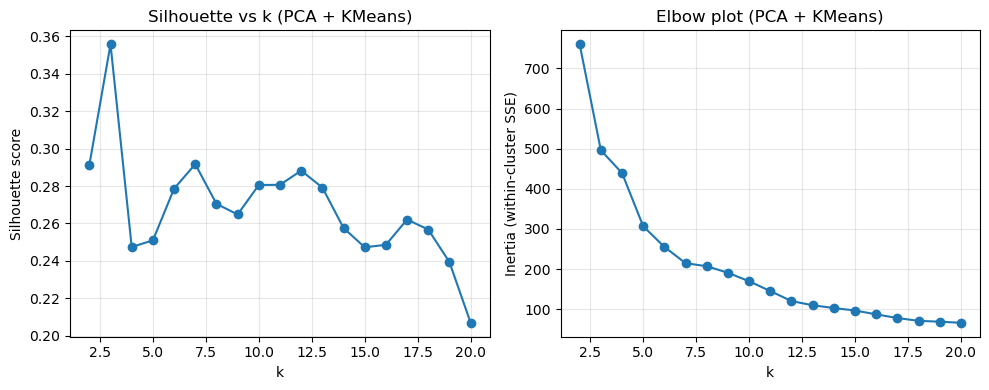

In [7]:
# Scan k for PCA+KMeans: silhouette scores and elbow plot


ks = range(2, 21)  # try k = 2..20


sil_scores = []
inertias = []


for k_scan in ks:
    km = KMeans(n_clusters=k_scan, random_state=0, n_init="auto")
    labels_k = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels_k)
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"k={k_scan:2d}  silhouette={sil:.3f}  inertia={km.inertia_:.1f}")


plt.figure(figsize=(10, 4))


# Silhouette score vs k
plt.subplot(1, 2, 1)
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (PCA + KMeans)")
plt.grid(True, alpha=0.3)


# Elbow plot: inertia vs k
plt.subplot(1, 2, 2)
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot (PCA + KMeans)")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [8]:
# Cluster farms in PCA space
k = 6  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X_pca)

# Store cluster labels (1..k)
df_smooth["profiles"] = labels + 1

In [9]:
# Optional: evaluate clustering quality
score = silhouette_score(X_pca, labels)
print(f"Silhouette score (PCA + KMeans, k={k}): {score:.3f}")

Silhouette score (PCA + KMeans, k=6): 0.279


In [11]:
# Define human‑readable names and fixed colors for each cluster.
# Edit these names/colors as you like. Make sure every cluster in df_features['cluster']
# has an entry here.
cluster_styles = {
    1: {"name": "Daytime increase", "color": "#1f77b4"},
    2: {"name": "Evening reduction", "color": "#ff7f0e"},
    3: {"name": "All-day low", "color": "#2ca02c"},
    4: {"name": "No difference", "color": "#d62728"},
    5: {"name": "Night-time increase", "color": "#9467bd"},
    6: {"name": "High-low", "color": "#8c564b"},
}

missing_clusters = set(df_smooth["profiles"].unique()) - set(cluster_styles)
if missing_clusters:
    print("Warning: no style defined for clusters:", sorted(missing_clusters))

/jobfs/156855168.gadi-pbs/ipykernel_1613504/3395973976.py:33: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64_any_dtype(idx) or pd.api.types.is_datetime64tz_dtype(idx):
/jobfs/156855168.gadi-pbs/ipykernel_1613504/3395973976.py:33: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64_any_dtype(idx) or pd.api.types.is_datetime64tz_dtype(idx):
/jobfs/156855168.gadi-pbs/ipykernel_1613504/3395973976.py:33: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64_any_dtype(idx) or pd.api.types.is_datetime64tz_dtype(idx):
/jobfs/156855168.gadi-pbs/ipykernel_1613504/3395973976.py:33: DeprecationWarning: is_

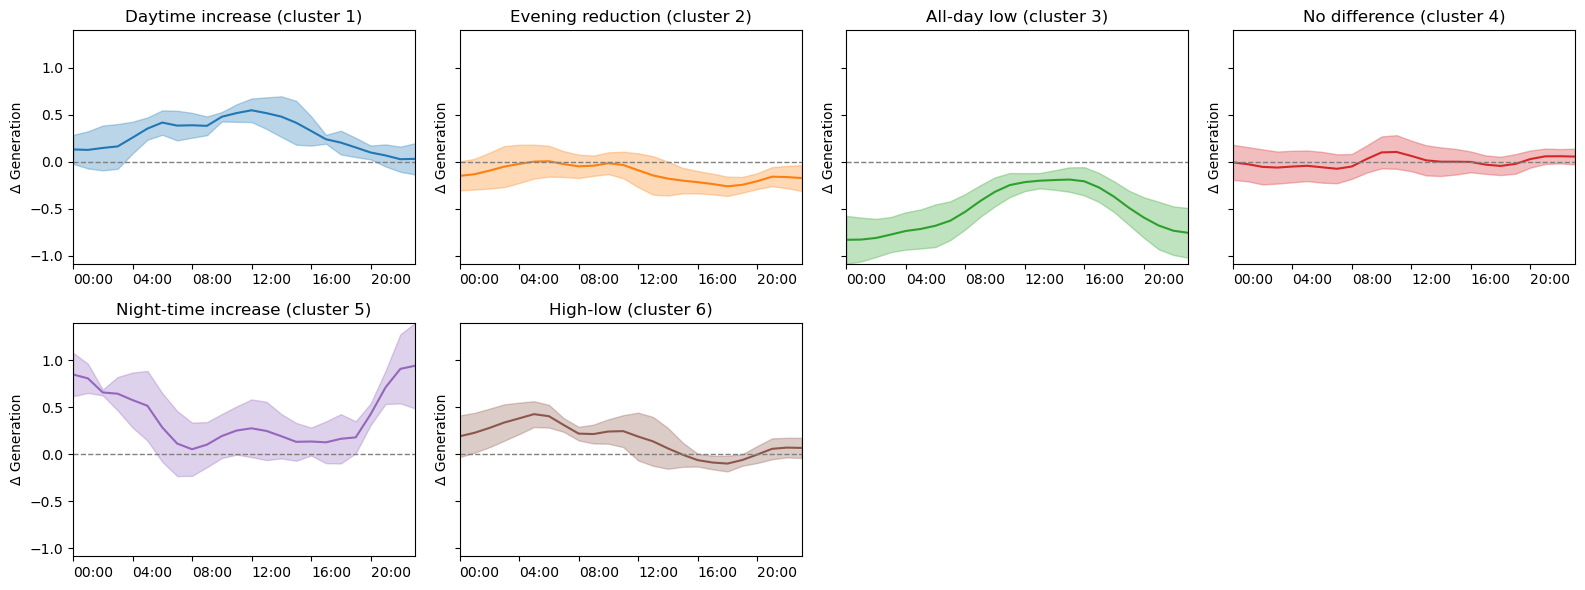

In [12]:
clusters = sorted(df_smooth["profiles"].unique())
n_clusters = len(clusters)
ncols = min(4, n_clusters)
nrows = math.ceil(n_clusters / ncols)

# Precompute means/stds and common y-limits
stats = {}
ymins, ymaxs = [], []
for c in clusters:
    cluster_curves = df_smooth[df_smooth["profiles"] == c].drop(columns="profiles")
    mean_curve = cluster_curves.mean()
    std_curve = cluster_curves.std().fillna(0)
    stats[c] = (mean_curve, std_curve)
    ymins.append((mean_curve - std_curve).min())
    ymaxs.append((mean_curve + std_curve).max())
ylim = (min(ymins), max(ymaxs))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 4, nrows * 3),
    sharex=True,
    sharey=True,
)  # keep sharex for aligned x-limits
axes = np.array(axes).reshape(-1)

for ax, c in zip(axes, clusters):
    mean_curve, std_curve = stats[c]
    color = cluster_styles.get(int(c), {}).get("color", "tab:blue")
    name = cluster_styles.get(int(c), {}).get("name", f"cluster {c}")
    idx = mean_curve.index

    if pd.api.types.is_datetime64_any_dtype(idx) or pd.api.types.is_datetime64tz_dtype(idx):
        x = idx
        ax.plot(x, mean_curve, color=color)
        ax.fill_between(
            x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.3,
            color=color,
        )

        # locator/formatter on each axis
        ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_minor_locator(mdates.HourLocator())
    else:
        x = mean_curve.index.astype(float)
        ax.plot(x, mean_curve, color=color)
        ax.fill_between(
            x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.3,
            color=color,
        )

        min_x, max_x = int(np.floor(x.min())), int(np.ceil(x.max()))
        step = 4
        ticks = np.arange(min_x, max_x + 1, step)
        labels = [f"{int(t):02d}:00" for t in ticks]
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels, rotation=0, ha='left')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f"{name} (cluster {c})")
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(*ylim)
    ax.set_ylabel("Δ Generation")

    # Force x tick labels to be visible on every subplot (overrides sharex default)
    ax.tick_params(axis='x', labelbottom=True)

# Turn off unused subplots
for ax in axes[len(clusters):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [18]:
# Load coordinates
duid_coords = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")[["DUID", "lat", "lon"]]

df_smooth.index.name = 'DUID'
map_df = (
    df_smooth[["profiles"]]
    .rename_axis('DUID')              # ensures the index has name 'DUID'
    .reset_index()
    .merge(duid_coords, on="DUID", how="left")
)

# Merge cluster labels with coordinates
map_df = df_smooth[["profiles"]].reset_index().merge(duid_coords, on="DUID", how="left")

# Check for missing coordinates
missing = map_df[["lat", "lon"]].isna().any(axis=1).sum()
if missing:
    print(f"Warning: {missing} DUIDs have missing coordinates and will be skipped on the map")

# Keep only valid rows
valid = map_df.dropna(subset=["lat", "lon"]).copy()

# Number of clusters
n_clusters_found = int(valid["profiles"].nunique())
default_cmap = cm.get_cmap("tab20", max(1, n_clusters_found))

# Map center
center = [valid["lat"].mean(), valid["lon"].mean()]
m = folium.Map(location=center, zoom_start=6, tiles="CartoDB.Positron")

# Jitter scale (adjust if needed)
jitter_scale = 0.02  # degrees (~2km)

# Add points to the map with jitter
for _, row in valid.iterrows():
    cl = int(row["profiles"])
    style = cluster_styles.get(cl, {})
    if "color" in style:
        color_hex = style["color"]
    else:
        rgba = default_cmap(cl - 1 if cl > 0 else 0)
        color_hex = colors.rgb2hex(rgba[:3])

    # Add jitter
    lat_jitter = row["lat"] + np.random.uniform(-jitter_scale, jitter_scale)
    lon_jitter = row["lon"] + np.random.uniform(-jitter_scale, jitter_scale)

    popup_name = style.get("name", f"Profile {cl}")
    popup = folium.Popup(
        f"DUID: {row['DUID']}<br>Profile: {cl} ({popup_name})",
        parse_html=True,
    )
    folium.CircleMarker(
        location=[lat_jitter, lon_jitter],
        radius=5,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

display(HTML(m._repr_html_()))

/jobfs/156855168.gadi-pbs/ipykernel_1613504/4203919055.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  default_cmap = cm.get_cmap("tab20", max(1, n_clusters_found))


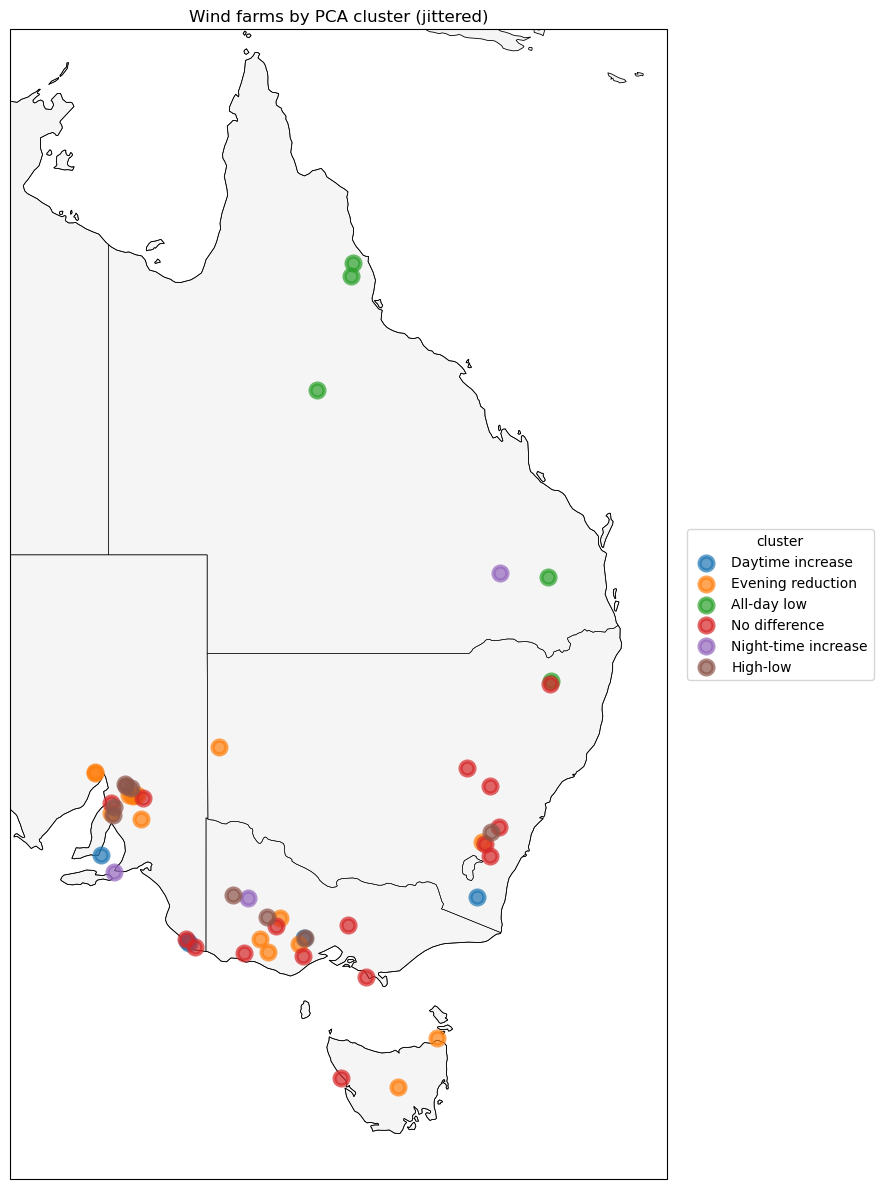

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

rng = np.random.default_rng(42)

jitter_lon = 0.1   # ~5 km
jitter_lat = 0.1

valid_jitter = valid.copy()
valid_jitter["lon_j"] = valid_jitter["lon"] + rng.normal(0, jitter_lon, len(valid))
valid_jitter["lat_j"] = valid_jitter["lat"] + rng.normal(0, jitter_lat, len(valid))


fig = plt.figure(figsize=(9, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Australia extent
ax.set_extent([135, 155, -45, -10], crs=ccrs.PlateCarree())

# Smooth background
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.4, zorder=2)

# Plot points by cluster
for cl in sorted(valid_jitter["profiles"].unique()):
    subset = valid_jitter[valid_jitter["profiles"] == cl]
    style = cluster_styles.get(int(cl), {})
    ax.scatter(
        subset["lon_j"],
        subset["lat_j"],
        s=100,
        color=style.get("color"),
        edgecolor=style.get("color"),
        linewidth=3,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=3,
        label=style.get("name", f"cluster {cl}")
    )

ax.set_title("Wind farms by PCA cluster (jittered)")
ax.legend(title="cluster", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()

plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_farms_profile_clusters.png")
plt.show()

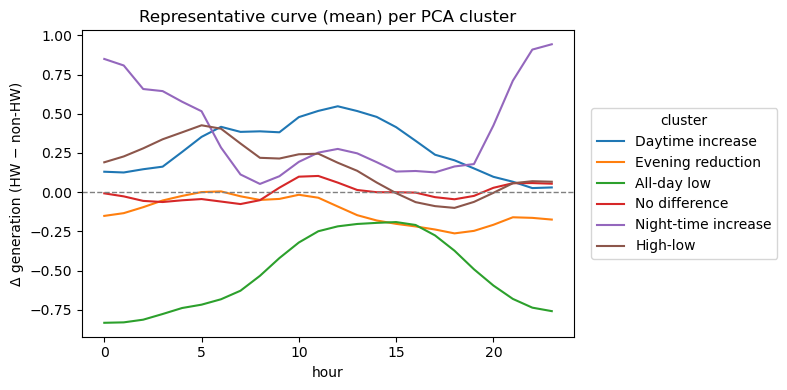

In [21]:
# Representative mean curve per PCA cluster (all clusters on one plot)

plt.figure(figsize=(8, 4))

hours = df_smooth.drop(columns="profiles").columns.to_numpy().astype(float)

for cl in sorted(df_smooth["profiles"].unique()):
    curves = df_smooth[df_smooth["profiles"] == cl].drop(columns="profiles")
    mean_curve = curves.mean(axis=0)
    style = cluster_styles.get(int(cl), {})
    color = style.get("color", None)
    label = style.get("name", f"cluster {cl}")
    plt.plot(hours, mean_curve, label=label, color=color)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel("hour")
plt.ylabel("Δ generation (HW − non‑HW)")
plt.title("Representative curve (mean) per PCA cluster")

plt.legend(
    title="cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()

plt.show()

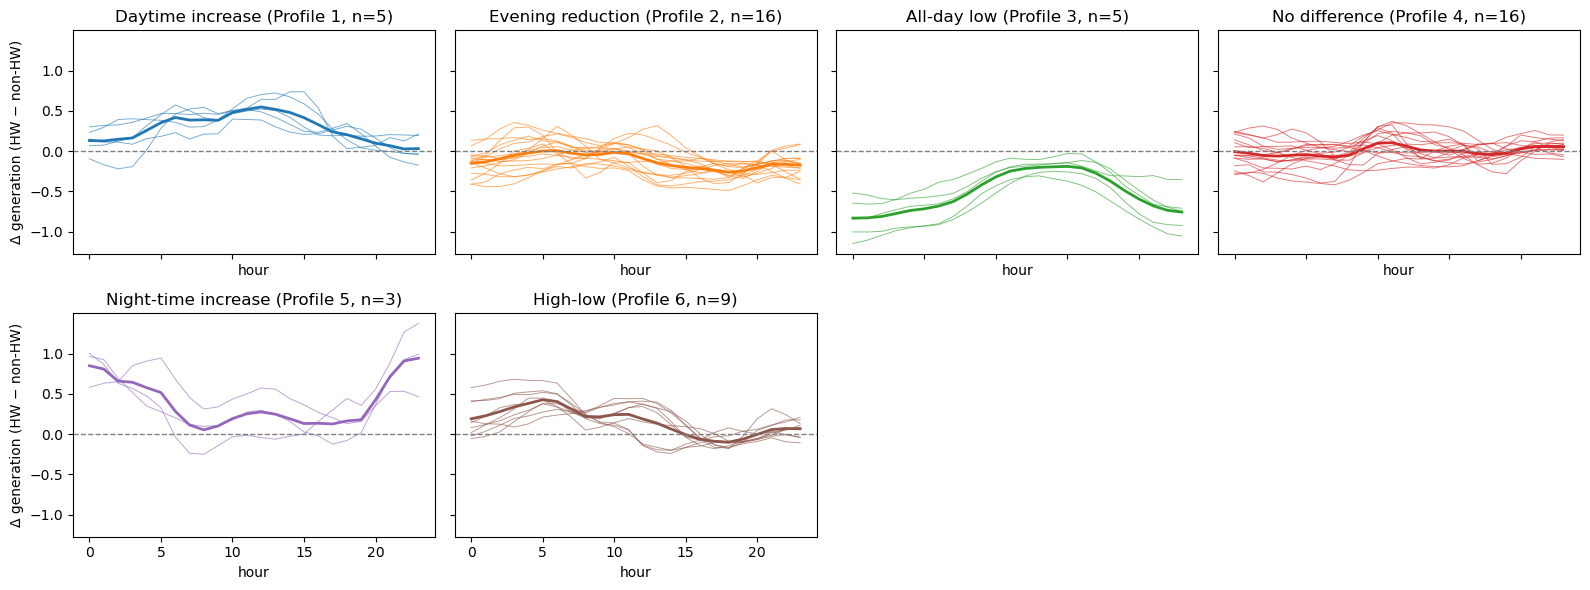

In [23]:
# sanity checks
if "profiles" not in df_smooth.columns:
    raise ValueError("df_smooth has no 'profiles' column; run the clustering cells first.")

clusters = sorted(df_smooth["profiles"].unique())
n_clusters = len(clusters)

# layout: up to 4 columns (change max_cols to taste)
max_cols = 4
cols = min(max_cols, n_clusters)
rows = math.ceil(n_clusters / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True, sharey=True)
axes = axes.flatten() if n_clusters > 1 else [axes]

for ax_idx, cluster_label in enumerate(clusters):
    ax = axes[ax_idx]
    style = cluster_styles.get(int(cluster_label), {})
    color = style.get("color", "tab:blue")
    name = style.get("name", f"cluster {cluster_label}")
    cluster_curves = df_smooth[df_smooth["profiles"] == cluster_label].drop(columns="profiles")
    # convert hour column names to floats (assumes columns are numeric-like)
    hours = cluster_curves.columns.to_numpy().astype(float)

    # plot individual curves
    for _, row in cluster_curves.iterrows():
        ax.plot(hours, row.values, color=color, linewidth=0.7, alpha=0.6)

    # plot mean
    mean_curve = cluster_curves.mean(axis=0)
    ax.plot(hours, mean_curve, color=color, linewidth=2, label="mean")

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{name} (Profile {cluster_label}, n={len(cluster_curves)})")
    if ax_idx % cols == 0:
        ax.set_ylabel("Δ generation (HW − non‑HW)")
    ax.set_xlabel("hour")

# hide any unused subplots
for j in range(len(clusters), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
reg_map = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_spatial_clusters.csv")[["DUID", "cluster"]]
# Combine region information with cluster labels
if "profiles" not in df_smooth.columns:
    raise ValueError("df_smooth has no 'profiles' column; run the clustering cells first.")

# df_smooth index is DUID; bring it into a column and merge with reg_map
spat_cluster = (
    df_smooth[["profiles"]]
    .reset_index()
    .rename(columns={"index": "DUID"})
    .merge(reg_map, on="DUID", how="left")
)

# Quick check of the mapping
display(spat_cluster.head())

# Plot number of DUIDs in each region
region_counts = (
    spat_cluster.groupby("cluster")["DUID"].nunique().sort_values(ascending=False)
)

,DUID,profiles,cluster
0,ARWF1,4,5
1,BALDHWF1,4,0
2,BLUFF1,4,2
3,BOCORWF1,1,3
4,BODWF1,4,3


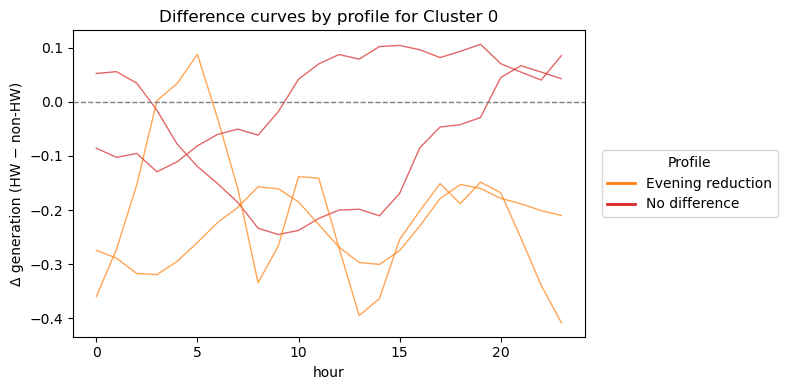

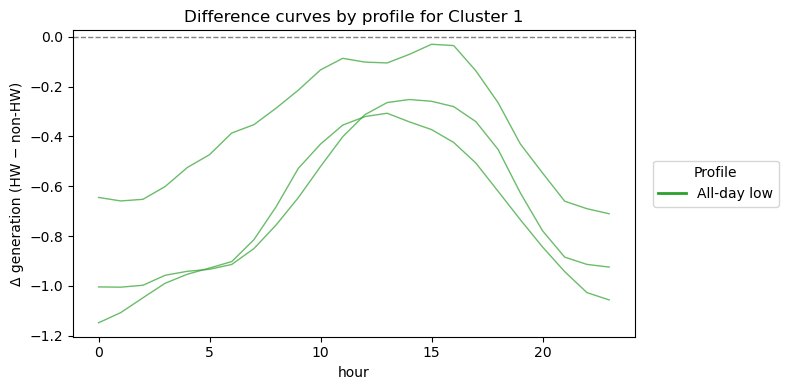

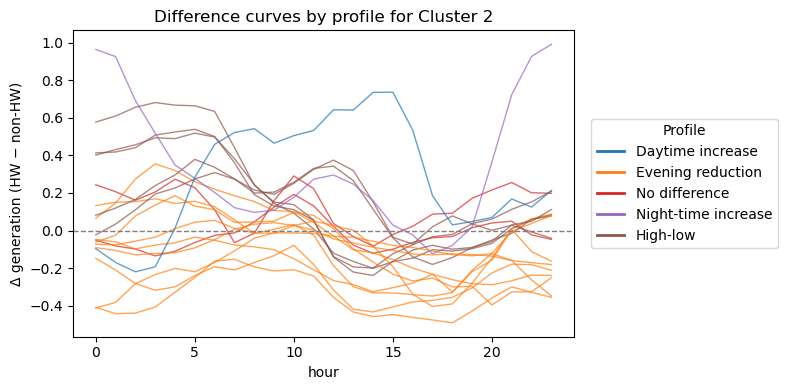

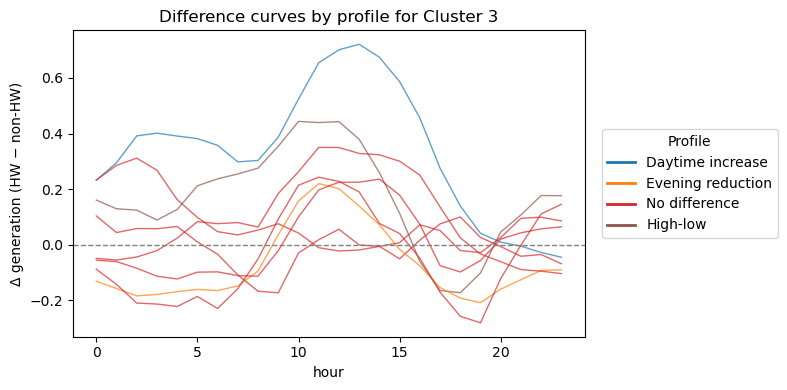

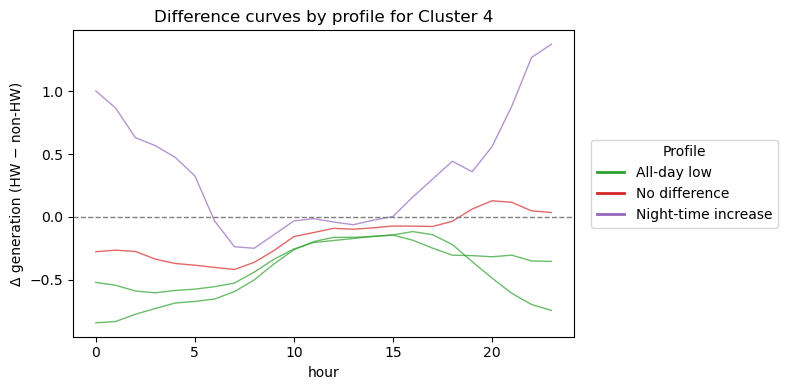

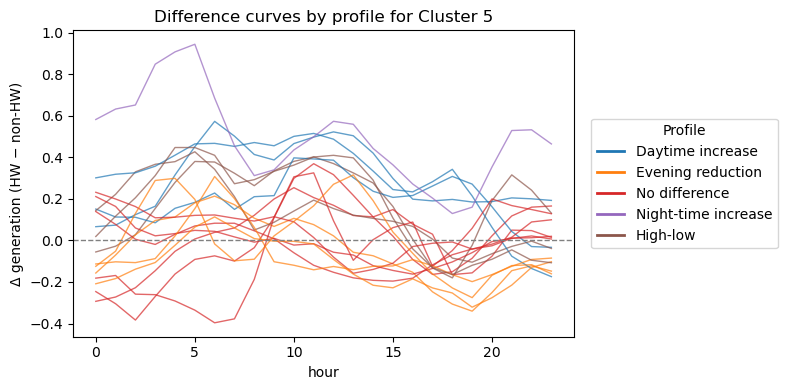

In [33]:
# Plot difference curves per region, coloured by cluster
from matplotlib.lines import Line2D

# Hours on the x-axis (assumes hour-like numeric column names)
hours = df_smooth.drop(columns="profiles").columns.to_numpy().astype(float)

# Global colour map for clusters
all_clusters = sorted(df_smooth["profiles"].unique())
cmap = plt.get_cmap("tab10", len(all_clusters))
cluster_to_color = {
    cl: cluster_styles.get(int(cl), {}).get("color", cmap(i))
    for i, cl in enumerate(all_clusters)
}

for region in sorted(spat_cluster["cluster"].dropna().unique()):
    duids = spat_cluster.loc[spat_cluster["cluster"] == region, "DUID"]
    if duids.empty:
        continue

    # Curves and clusters for this region
    curves = df_smooth.loc[duids].drop(columns="profiles")
    clusters_region = df_smooth.loc[duids, "profiles"]

    plt.figure(figsize=(8, 4))

    for duid in duids:
        curve = curves.loc[duid].values
        cl = int(clusters_region.loc[duid])
        color = cluster_to_color.get(cl, "grey")
        plt.plot(hours, curve, color=color, alpha=0.7, linewidth=1)

    # Legend showing clusters present in this region
    clusters_here = sorted(clusters_region.unique())
    legend_elems = [
        Line2D(
            [0],
            [0],
            color=cluster_to_color[int(cl)],
            lw=2,
            label=cluster_styles.get(int(cl), {}).get("name", f"cluster {int(cl)}"),
        )
        for cl in clusters_here
    ]

    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("hour")
    plt.ylabel("Δ generation (HW − non‑HW)")
    plt.title(f"Difference curves by profile for Cluster {region}")
    plt.legend(
        handles=legend_elems,
        title="Profile",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    plt.tight_layout()
    plt.show()

### 